# 🧪 Experiment EIC_120 — Policy Selection with SMAC3


## 📝 Introduction

## 📦 Imports

Here we define all required imports to conduct our experiment.

In [3]:
# Imports
import numpy as np

# Optional: in-notebook sanity check (no-op when installed)
from inventory.evaluation.notebooks.bootstrap import ensure_inventory_imports
ensure_inventory_imports(verbose=False)

# Evaluation
from inventory.evaluation import make_eval_info
from inventory.evaluation.reporting import summarize_totals

# Plotting
from inventory.evaluation.plotting import plot_multi_regime_sample_path

# Dynamic system framework
from inventory.core.dynamics import DynamicSystem

# Problem definitions
from inventory.problems.inventory_mvp import inventory_transition_regime_capped, inventory_cost_extended_capped

# Demand model (exogenous)
from inventory.problems.demand_models import ExogenousPoissonMultiRegime

# Forecast providers
from inventory.forecasters import ExogenousAwareMeanForecaster,MlRegimeDemandForecaster, MultiRegimeFeatureAdapter
from inventory.forecasters.naive import ConstantMeanForecaster, NaiveForecaster

# Policies
from inventory.policies.baselines import OrderUpToPolicy
from inventory.policies.hybrid_dla import HybridDlaRolloutComposablePolicy
from inventory.policies.cfa_milp import OrderMilpCfaPolicy
from inventory.policies.dla_milp import DlaMpcMilpPolicy
from inventory.policies.dla_mcts import DlaMctsUctPolicy, DlaMctsUctRolloutPolicy
from inventory.policies.hybrid_dla import (HybridDlaDeterministicComposablePolicy,HybridDlaRolloutComposablePolicy,InventoryLinearTerminalValue)
from inventory.evaluation.policy_automl import (
    PolicyAutoMLDemoProblem,
    build_policy_from_config,
    run_policy_automl_smac3,
    smac_policy_menu_to_search_space_config,
)


---

## 🚧 Problem definition

In this experiment we use our benchmark inventory problem with **observable multi-regime Poisson demand** and our standard set of cost parameters. Keeping this problem definition close to the constant-demand experiments helps us isolate what changes once the policy can exploit season/day/weather structure.


In [4]:
# === Defining the dynamic system ===

# Simulation horizon
T = 360

# Initial Inventory
# Start in (inventory=300, season=Summer=2, day=Monday=0, weather=Sunny=2)
S0= np.array([300.0, 2.0, 0.0, 2.0], dtype=float)
#S0= np.array([300.0, 3.0, 0.0, 2.0], dtype=float)

# Constraints
x_max = 480
dx = 10
S_max = 480

# Exogenous demand
exo = ExogenousPoissonMultiRegime(season_index=1, day_index=2, weather_index=3, season_period=90)

# Cost parameters 
p, c, h, b, K = 2.0, 0.5, 0.03, 1.0, 10.0

# Transition function
transition_func = lambda s, a, w, t: inventory_transition_regime_capped(s, a, w, t, s_max=S_max)

# Cost functions
cost_func = lambda s, a, w, t: inventory_cost_extended_capped(s, a, w, t, p=p, c=c, h=h, b=b, K=K, s_max=S_max)

# Dynamic System
system = DynamicSystem(
    transition_func=transition_func,
    cost_func=cost_func,
    exogenous_model=exo,
    sim_seed=42,
    d_s=4,
    d_x=1,
    d_w=4,
 )

# Strict-CRN Monte Carlo evaluation settings
seed0 = 1234
n_episodes = 200
eval_info = make_eval_info(T=T, det_mode='argmax')
eval_info

{'deterministic': True, 'det_mode': 'argmax', 'T': 360}

To get an idea about the kind of demand pattern we are dealing with in this problem setting, let us have a lookt at one expamplary demand that matches the CRN “reference episode” seed stream.

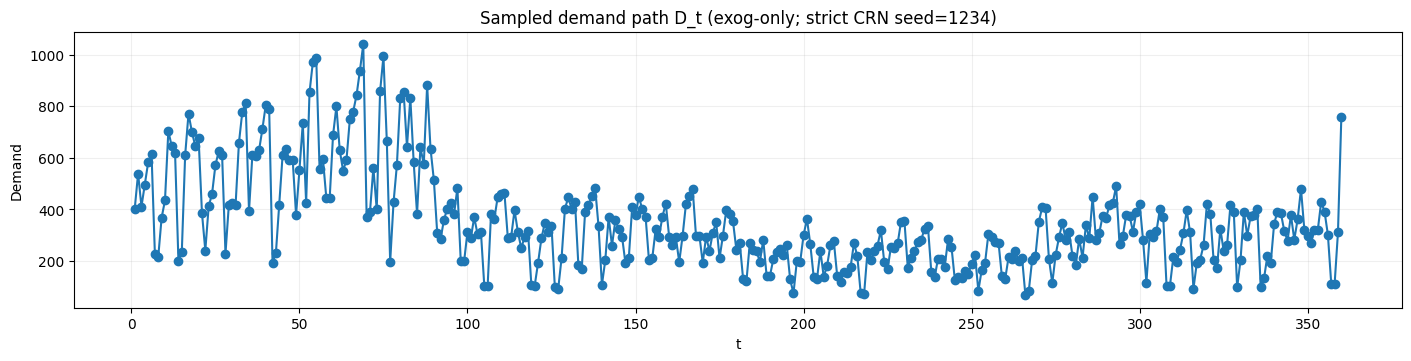

In [5]:
_ = plot_multi_regime_sample_path(exo,T, seed0, state0=S0, figsize=(14, 3.5), demand_only=True)

---

## 🔮 Forecaster defintion

In this section, we specify which information model (a.k.a. **forecaster**) the policy uses to anticipate future demand. Therefore we first instantiate the feature adapter for the respective exogenous model, second select the forecaster class with resptective paramenter settings, third, generate training and test data, and fourth, train the forecaster and plot its performance KPIs.

Next, we conclude with a short sanity check to ensure that the resulting predictions are reasonable before they are embedded into the policy.

In [6]:
# === Naive Forecaster ===
# Naive forecaster: repeat the last observed demand for the next H steps.
# For the initial fallback, use the effective Poisson mean implied by the current multi-regime state.
mu0_multi_regime = exo.lambda_for_regimes(
    int(S0[exo.season_index]),
    int(S0[exo.day_index]),
    int(S0[exo.weather_index]),
)
forecaster_naive = NaiveForecaster(default_value=float(mu0_multi_regime))
# Print example prediction: Planned info payload passed into the CFA policy / forecaster call
naive_info_demo = {"last_demand": [295.0]}
H_demo = 7
mu_demo_naive = forecaster_naive.forecast_mean_path(S0, t=0, H=H_demo, info=naive_info_demo)
print("mu0_multi_regime:", float(mu0_multi_regime))
print("naive_info_demo:", naive_info_demo)
print(f"mu_demo_naive (H={H_demo}):", np.round(mu_demo_naive, 2))

mu0_multi_regime: 582.0
naive_info_demo: {'last_demand': [295.0]}
mu_demo_naive (H=7): [295. 295. 295. 295. 295. 295. 295.]


In [7]:
# === Constant Forecaster ===
# Constant-mean forecaster: freeze the current regime-implied demand mean across the horizon.
forecaster_const_300 = ConstantMeanForecaster(mean=float(300.0))

# Print example prediction: forecast mean demand path
H_demo = 7
mu_demo_const = forecaster_const_300.forecast_mean_path(S0, t=0, H=H_demo)
print(f"mu_demo_const (H={H_demo}):", np.round(mu_demo_const, 2))

mu_demo_const (H=7): [300. 300. 300. 300. 300. 300. 300.]


In [8]:
# === ML Forecaster ===
# Use the regime-aware adapter and forecaster so the model can condition on season, day, and weather.
adapter = MultiRegimeFeatureAdapter(exo)
forecaster_ml_tree = MlRegimeDemandForecaster(
    adapter, 
    model_type="tree", 
    tree_max_depth=6,
    min_samples_leaf=20,
    random_state=0)

# Train on synthetic data generated from the multi-regime exogenous model
fit_seed = 7
val_seed = 99

forecaster_ml_tree.fit_from_exogenous(
    n_samples=60000,
    seed=fit_seed,
    t_start=0,
    val_samples=1000,
    val_seed=val_seed,
    val_t_start=8000,
 )

# Print ML forecaster fit report summary
print("ML forecaster fit_report (summary):")
print("  model_type:", forecaster_ml_tree.fit_report.get("model_type"))
print("  feature_dim:", forecaster_ml_tree.fit_report.get("feature_dim"))
for split in ("train", "val"):
    rep = forecaster_ml_tree.fit_report.get(split, {})
    mae = rep.get("MAE")
    rmse = rep.get("RMSE")
    bias = rep.get("Bias")
    n = rep.get("n_samples")
    print(f"  {split}: n={n} | MAE={mae:.3f} | RMSE={rmse:.3f} | Bias={bias:.3f}")

ML forecaster fit_report (summary):
  model_type: tree
  feature_dim: 15
  train: n=60000 | MAE=64.065 | RMSE=83.463 | Bias=0.000
  val: n=1000 | MAE=64.613 | RMSE=83.864 | Bias=0.127


In [9]:
# Print example prediction: forecast mean demand path for the current multi-regime state
H_demo = 7
mu_demo = forecaster_ml_tree.forecast_mean_path(S0, t=0, H=H_demo)
print(f"\nmu_demo (H={H_demo}):", np.round(mu_demo, 2))

S_test= np.array([300.0, 2.0, 0.0, 2.0], dtype=float)
mu_demo = forecaster_ml_tree.forecast_mean_path(S_test, t=0, H=H_demo)
print(f"\nmu_demo (H={H_demo}):", np.round(mu_demo, 2))


mu_demo (H=7): [480.13 662.36 662.36 662.36 830.93 795.08 402.24]

mu_demo (H=7): [480.13 662.36 662.36 662.36 830.93 795.08 402.24]


---

## 🤖 Policy definition

In this section, we define the policies under investigation and collect them in a policy dictionary used by our strict-CRN evaluation pipeline.

The first policy is the canonical benchmark `OrderUpTo`. The second policy is the main candidate that we want to compare against this benchmark. The third policy is a controlled variation of the candidate, included to examine one targeted variation of interest.

This set of policies enables a structured comparison and helps us address our research questions.

### === Heuristic Policies ===

In [10]:
# === Baseline Policy ===
# Baseline: a fixed order-up-to target used both as a benchmark and as a simple proposal/continuation policy.
OrderUpTo_350 = OrderUpToPolicy(target_level=350.0, x_max=x_max, dx=dx)


---

### === PFA Policy Class ===

In [11]:
# Train the candidate_policy
# Source: EIMR_032_OrderUpToBlackboxPFA_vs_baseline_vs_dp_capped.ipynb

from inventory.policies.pfa import OrderUpToBlackboxPFA, DirectActionPFA

# === Additional form of Candidate: DirectActionPFA (Decision Tree, deeper) ===
# Uses DirectActionPFA with a DecisionTreeRegressor (max_depth=8).
# Variation of candidate_var3: allows deeper splits to capture more complex
# state-action structure. Useful to examine whether more expressive trees
# improve or overfit relative to the shallower candidate_var3.

from sklearn.tree import DecisionTreeRegressor


def feature_fn_inventory_regime_time(s, t):
    return np.array([s[0], s[1], s[2], s[3], float(t)], dtype=float)


DirectActionPFA_Tree = DirectActionPFA(
    system=system,
    x_max=x_max,
    dx=dx,
    regressor=DecisionTreeRegressor(max_depth=8, random_state=seed0),
    # Expose inventory + season + day + weather + time to the regressor
    feature_fn=feature_fn_inventory_regime_time,
)

do_optimize = True
if do_optimize:
    DirectActionPFA_Tree.fit_via_rollout_improvement(
        S0=S0,
        T=T,
        n_episodes=400,# “How much rollout-labeled data do we collect per outer iteration?”
        seed0=seed0+5000,
        n_iter=3,#4, #“How many times do we alternate between fitting a policy and recollecting data under that improved policy?”
        info=eval_info,
    ) 

print(DirectActionPFA_Tree)

DirectActionPFA(regressor=DecisionTreeRegressor(max_depth=8, random_state=1234), x_max=480.0, dx=10, H=5, status=fitted)


---

### === CFA Policies ===

In [24]:
# === CFA Policy: Forecast-based CFA ===
# MILP CFA - based adjustable policy form
MilpCFA_forecaster_ml = OrderMilpCfaPolicy(
    forecaster=forecaster_ml_tree, # use the forecaster's full mean path
    H=3,
    x_max=x_max,dx=dx,S_max=S_max,
    p=p,c=c,h=h,b=b,K=K,
 )

---

### === VFA Policies ===

In [35]:
# Insert police here

---

### === DLA Polices ===

In [22]:
# === Candidate Policy ===
# Candidate: DLA MPC via a deterministic surrogate MILP (re-solve every period, execute first action only)
# - H controls planning horizon
# - Uses the demand mean path mu[t:t+H) from the exogenous model (or a forecaster if supplied)
H = 7
DlaMpcMilp_H7_ml_tree = DlaMpcMilpPolicy(
    model=system,
    H=int(H),
    x_max=float(x_max),
    dx=int(dx),
    S_max=float(S_max),
    p=float(p),
    c=float(c),
    h=float(h),
    b=float(b),
    K=float(K),
    forecaster=forecaster_ml_tree

 )

In [12]:
# === Candidate Policy ===
# Candidate: DLA via Monte Carlo Tree Search (UCT) on the simulator model

# Parameters to control the candidate policy's speed vs quality tradeoff:
# - horizon: planning depth (tree depth)
# - n_simulations: number of tree simulations per decision
# - uct_c: exploration constant (higher => more exploration)


# Select policy profile to trade off speed vs quality:
profile = "quality"  # "fast" | "quality"

if profile == "fast":
    horizon = 4
    n_simulations = 60
    uct_c = 1.4
elif profile == "quality":
    horizon = 7#6
    n_simulations = 250
    uct_c = 1.6
else:
    raise ValueError("profile must be 'fast' or 'quality'")

# Define the candidate policy
DlaMctsUct_H7_quality = DlaMctsUctPolicy(
    model=system,
    horizon=int(horizon),
    n_simulations=int(n_simulations),
    uct_c=float(uct_c),
    x_max=float(x_max),
    dx=int(dx),
    planning_seed=7,
 )

---

### === Hybrid Policies ===

#### === DLA + Heuristic ===

In [14]:
# === Rollout composable hybrid ===
# This policy evaluates candidate first actions by simulation, then follows
# the baseline continuation policy over the remaining rollout horizon.

hybrid_rollout = HybridDlaRolloutComposablePolicy(
    system=system,
    rollout_policy=OrderUpTo_350,
    candidate_policy=OrderUpTo_350,
    H=3,#7,
    n_rollouts=10,#30,
    dx=dx,
    x_max=x_max,
    decision_seed=2026,
    candidate_radius_steps=2,#5,
    include_full_action_grid=False,
)

#### === DLA + PFA ===

In [13]:
# Build the hybrid class

# === Rollout composable hybrid ===
# This policy evaluates candidate first actions by simulation, then follows
# the baseline continuation policy over the remaining rollout horizon.

hybrid_rollout_pfa_tree = HybridDlaRolloutComposablePolicy(
    system=system,
    rollout_policy=DirectActionPFA_Tree,#baseline,
    candidate_policy=DirectActionPFA_Tree,
    H=3,#7,
    n_rollouts=10,#30,
    dx=dx,
    x_max=x_max,
    decision_seed=2026,
    candidate_radius_steps=2,#5,
    include_full_action_grid=False,
)

---

## 🧠 AutoML policy search with SMAC3

In [15]:
from inventory.evaluation.policy_automl import (
    PolicyAutoMLDemoProblem,
    build_policy_from_config,
    run_policy_automl_smac3,
    smac_policy_menu_to_search_space_config,
)

In [ ]:
import pandas as pd

# Notebook-visible policy menu: phase 1 separates tunable families from pre-trained artifacts.
smac_policy_menu = {
    "tunable_families": {
        "order_up_to": {
            "policy_class": "OrderUpToPolicy",
            "search_hyperparameter": "target_level",
            "bounds": (0, int(S_max)),
            "grid_step": int(dx),
        },
        "cfa_milp": {
            "policy_class": "OrderMilpCfaPolicy",
            "search_hyperparameter": "H",
            "bounds": (1, 5),
            "forecaster_key": ("naive","ml_tree"),
        },
        "dla_mpc": {
            "policy_class": "DlaMpcMilpPolicy",
            "search_hyperparameter": "H",
            "bounds": (1, 5),
            "forecaster_key": "naive",
        },
    },
    "trainable_families": {
        "direct_action_pfa": {
            "policy_class": "DirectActionPFA",
            "regressor_modes": ("decision_tree", "elastic", "mlp"),
            "train_n_episodes_bounds": (200, 200),
            "train_n_iter_bounds": (3, 3),
            "H": 5,
            "feature_fn_key": "inventory_regime_time",
            "model_hyperparameters": {
                "decision_tree": {
                    "tree_max_depth_bounds": (3, 10),
                },
                "elastic": {
                    "elastic_alpha_bounds": (0.001, 1.0),
                    "elastic_l1_ratio_bounds": (0.1, 0.9),
                },
            },
        },
    },
    "composite_families": {
        "hybrid_rollout_choice": {
            "policy_class": "HybridDlaRolloutComposablePolicy",
            "rollout_policy_choices": ("OrderUpTo_350", "DirectActionPFA_Tree"),
            "candidate_policy_choices": ("OrderUpTo_350", "DirectActionPFA_Tree"),
            "fixed_params": {
                "H": 3,
                "n_rollouts": 5,
                "candidate_radius_steps": 1,
                "include_full_action_grid": False,
                "decision_seed": 2026,
            },
        },
    },
    "prefit_variants": {
        #"DirectActionPFA_Tree": {
        #    "policy_class": "DirectActionPFA",
        #    "role": "prefit_artifact",
        #    "description": "Decision-tree direct-action PFA trained offline before SMAC",
        #},
        "DlaMctsUct_H7_quality": {
            "policy_class": "DlaMctsUctPolicy",
            "role": "prefit_artifact",
            "description": "Pre-built UCT-MCTS policy with horizon=7, n_simulations=250, uct_c=1.6",
        },
    },
}

smac_policy_menu_df = pd.DataFrame(
    [
        {
            "group": "tunable_families",
            "name": family,
            "policy_class": spec["policy_class"],
            "search_hyperparameter": spec["search_hyperparameter"],
            "range_or_choices": spec.get("bounds", spec.get("choices")),
        }
        for family, spec in smac_policy_menu["tunable_families"].items()
    ]
    + [
        {
            "group": "trainable_families",
            "name": family,
            "policy_class": spec["policy_class"],
            "search_hyperparameter": "regressor_mode, train_n_episodes, train_n_iter",
            "range_or_choices": {
                "regressor_modes": spec["regressor_modes"],
                "train_n_episodes_bounds": spec["train_n_episodes_bounds"],
                "train_n_iter_bounds": spec["train_n_iter_bounds"],
                "H": spec["H"],
                "feature_fn_key": spec.get("feature_fn_key"),
                "model_hyperparameters": spec.get("model_hyperparameters", {}),
            },
        }
        for family, spec in smac_policy_menu["trainable_families"].items()
    ]
    + [
        {
            "group": "composite_families",
            "name": family,
            "policy_class": spec["policy_class"],
            "search_hyperparameter": "rollout_policy_key, candidate_policy_key",
            "range_or_choices": {
                "rollout_policy_choices": spec["rollout_policy_choices"],
                "candidate_policy_choices": spec["candidate_policy_choices"],
                "fixed_params": spec.get("fixed_params", {}),
            },
        }
        for family, spec in smac_policy_menu["composite_families"].items()
    ]
    + [
        {
            "group": "prefit_variants",
            "name": name,
            "policy_class": spec["policy_class"],
            "search_hyperparameter": "prefit_name",
            "range_or_choices": name,
        }
        for name, spec in smac_policy_menu["prefit_variants"].items()
    ]
)
smac_policy_menu_df

smac_problem = PolicyAutoMLDemoProblem(
    name="multi_regime_inventory_notebook",
    system=system,
    exogenous_model=exo,
    S0=S0,
    T=int(T),
    x_max=int(x_max),
    dx=int(dx),
    s_max=int(S_max),
    p=float(p),
    c=float(c),
    h=float(h),
    b=float(b),
    K=float(K),
    eval_info=dict(eval_info),
    train_info=dict(eval_info),
    forecaster_registry={"naive": forecaster_naive, "ml_tree": forecaster_ml_tree},
    feature_fn_registry={"inventory_regime_time": feature_fn_inventory_regime_time},
    default_cfa_forecaster_key="naive",
    default_dla_forecaster_key="naive",
    prefit_policy_registry={
        "DirectActionPFA_Tree": DirectActionPFA_Tree,
        "DlaMctsUct_H7_quality": DlaMctsUct_H7_quality,
    },
    component_policy_registry={
        "OrderUpTo_350": OrderUpTo_350,
        "DirectActionPFA_Tree": DirectActionPFA_Tree,
    },
)

# Optional display: show how the notebook-facing menu maps to helper-layer SMAC kwargs.
smac_search_space_config = smac_policy_menu_to_search_space_config(smac_policy_menu)
smac_search_space_config

# Search-time budget: intentionally smaller than the final hold-out evaluation.
smac_n_trials = 5
smac_search_episodes = 40
smac_search_seed0 = 20260209
smac_train_seed0 = smac_search_seed0 + 50000
smac_scenario_seed = 123
smac_runtime_penalty = 0.0

smac_result = run_policy_automl_smac3(
    smac_problem,
    n_trials=smac_n_trials,
    scenario_seed=smac_scenario_seed,
    n_episodes=smac_search_episodes,
    seed0=smac_search_seed0,
    training_seed0=smac_train_seed0,
    runtime_penalty=smac_runtime_penalty,
    eval_info=eval_info,
    train_info=eval_info,
    policy_menu=smac_policy_menu,
)

smac_incumbent_config = smac_result.incumbent_config
smac_incumbent_label = smac_result.incumbent_label
smac_incumbent_policy = smac_result.incumbent_policy
if smac_incumbent_policy is None:
    smac_incumbent_policy = build_policy_from_config(smac_incumbent_config, smac_problem)

print("=== SMAC incumbent ===")
print("label:", smac_incumbent_label)
print("config:", smac_incumbent_config)
print("score:", round(smac_result.incumbent_score, 3))

smac_runhistory_df = pd.DataFrame(smac_result.runhistory_rows)
smac_runhistory_df


/Users/christopherlisson/Projects/sdam_introduction/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/christopherlisson/Projects/sdam_introduction/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/christopherlisson/Projects/sdam_introduction/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/christopherlisson/Projects/sdam_introduction/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/christopherlisson/Projects/sdam_introduction/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  r

=== SMAC incumbent ===
label: HybridRollout[rollout=OrderUpTo_350, candidate=DirectActionPFA_Tree]
config: {'label': 'HybridRollout[rollout=OrderUpTo_350, candidate=DirectActionPFA_Tree]', 'family': 'hybrid_rollout_choice', 'rollout_policy_key': 'OrderUpTo_350', 'candidate_policy_key': 'DirectActionPFA_Tree', 'H': 3, 'n_rollouts': 5, 'candidate_radius_steps': 1, 'include_full_action_grid': False, 'decision_seed': 2026}
score: -146766.751


,rank,label,family,score
0,1,"HybridRollout[rollout=OrderUpTo_350, candidate...",hybrid_rollout_choice,-146766.751
1,2,"HybridRollout[rollout=OrderUpTo_350, candidate...",hybrid_rollout_choice,-146766.751
2,3,"HybridRollout[rollout=OrderUpTo_350, candidate...",hybrid_rollout_choice,-146766.751
3,4,"HybridRollout[rollout=OrderUpTo_350, candidate...",hybrid_rollout_choice,-146766.751
4,5,"HybridRollout[rollout=OrderUpTo_350, candidate...",hybrid_rollout_choice,-146766.751
5,6,"HybridRollout[rollout=OrderUpTo_350, candidate...",hybrid_rollout_choice,-146766.751
6,7,"HybridRollout[rollout=OrderUpTo_350, candidate...",hybrid_rollout_choice,-146766.751
7,8,PrefitPolicy[DlaMctsUct_H7_quality],prefit_policy,-142882.309
8,9,PrefitPolicy[DlaMctsUct_H7_quality],prefit_policy,-142882.309
9,10,PrefitPolicy[DlaMctsUct_H7_quality],prefit_policy,-142882.309


In [17]:
# === SMAC runhistory: unique configurations (compact teaching view) ===
pd.set_option("display.max_colwidth", None)
smac_unique_df = (
    pd.DataFrame(smac_result.runhistory_rows)
    .groupby(["label", "family"], as_index=False)
    .agg(
        best_score=("score", "min"),
        n_visits=("score", "size"),
    )
    .sort_values(["best_score", "label"], ascending=[True, True])
    .reset_index(drop=True)
)

smac_unique_df

,label,family,best_score,n_visits
0,"HybridRollout[rollout=OrderUpTo_350, candidate=DirectActionPFA_Tree]",hybrid_rollout_choice,-146766.751,7
1,PrefitPolicy[DlaMctsUct_H7_quality],prefit_policy,-142882.309,30
2,"DirectActionPFA[mlp, neps=200, niter=3]",direct_action_pfa,-138928.837,1
3,"DirectActionPFA[elastic, neps=200, niter=3, alpha=0.127, l1=0.89]",direct_action_pfa,-134965.844,1
4,DLA_MPC[H=4],dla_mpc,-134668.645,1
5,CFA_MILP[H=5],cfa_milp,-132132.932,1
6,CFA_MILP[H=3],cfa_milp,-131742.541,1
7,DLA_MPC[H=3],dla_mpc,-131742.541,1
8,DLA_MPC[H=1],dla_mpc,-124058.546,1
9,"HybridRollout[rollout=DirectActionPFA_Tree, candidate=OrderUpTo_350]",hybrid_rollout_choice,-119533.838,3


---

###  === 📦 Experimental Setup ===

In [25]:
# === Collect policies into a dictionary for easy access in evaluation/reporting code ===
policies = {
    'OrderUpTo_350': OrderUpTo_350,
    'DirectActionPFA_Tree': DirectActionPFA_Tree,
    'MilpCFA_forecaster_ml': MilpCFA_forecaster_ml,
    'DlaMpcMilp_H7_ml_tree':DlaMpcMilp_H7_ml_tree,
    #'hybrid_rollout_heuristic': hybrid_rollout,
    'hybrid_rollout_pfa_tree': hybrid_rollout_pfa_tree,
    "smac_incumbent": smac_incumbent_policy,
}

print('==== Policy Parameters ====')
policies


==== Policy Parameters ====


{'OrderUpTo_350': OrderUpToPolicy(target_level=350.0, x_max=480, dx=10),
 'DirectActionPFA_Tree': DirectActionPFA(regressor=DecisionTreeRegressor(max_depth=8, random_state=1234), x_max=480.0, dx=10, H=5, status=fitted),
 'MilpCFA_forecaster_ml': OrderMilpCfaPolicy(H=3, x_max=480.0, dx=10, S_max=480.0, p=2.0, c=0.5, h=0.03, b=1.0, K=10.0, alpha=None, forecaster='MlRegimeDemandForecaster'),
 'DlaMpcMilp_H7_ml_tree': DlaMpcMilpPolicy(H=7, x_max=480.0, dx=10, S_max=480.0, p=2.0, c=0.5, h=0.03, b=1.0, K=10.0, forecaster='MlRegimeDemandForecaster'),
 'hybrid_rollout_pfa_tree': HybridDlaRolloutComposablePolicy(rollout_policy='DirectActionPFA', candidate_policy='DirectActionPFA', H=3, n_rollouts=10, dx=10, x_max=480, decision_seed=2026, candidate_radius_steps=2, include_full_action_grid=False, adaptive_candidate_radius=False, adaptive_radius_near=2, adaptive_radius_far=8, adaptive_gap_threshold=40.0, rollout_history_window=0),
 'smac_incumbent': HybridDlaRolloutComposablePolicy(rollout_policy=

---

## 🪄 Experiment run and Strict-CRN policy evaluation

In this section, we evaluate all policies under identical sampled exogenous paths using strict CRN. This ensures a fair comparison and allows us to summarize and illustrate the resulting performance differences.

In [26]:
# === Experiment run and Strict-CRN policy evaluation ===
from inventory.evaluation.notebooks.crn_runs import run_crn_mc

run = run_crn_mc(
    system=system,
    policies=policies,
    S0=S0,
    T=T,
    n_episodes=100,#n_episodes,
    seed0=seed0,
    info=eval_info,
    print_summary=True,
)

results = run.results
rollouts = run.rollouts
totals_by_policy = run.totals_by_policy
totals_summary = run.totals_summary

=== Final CRN-MC totals (lower is better) ===
OrderUpTo_350   | mean=-116159.822 | std=2378.051 | n=100 | runtime=1.188s
DirectActionPFA_Tree | mean=-146245.942 | std=2222.268 | n=100 | runtime=4.003s
MilpCFA_forecaster_ml | mean=-138363.619 | std=1729.664 | n=100 | runtime=81.362s
DlaMpcMilp_H7_ml_tree | mean=-138686.512 | std=1749.085 | n=100 | runtime=354.057s
hybrid_rollout_pfa_tree | mean=-147812.615 | std=2243.067 | n=100 | runtime=276.945s
smac_incumbent  | mean=-147066.379 | std=2242.264 | n=100 | runtime=57.981s


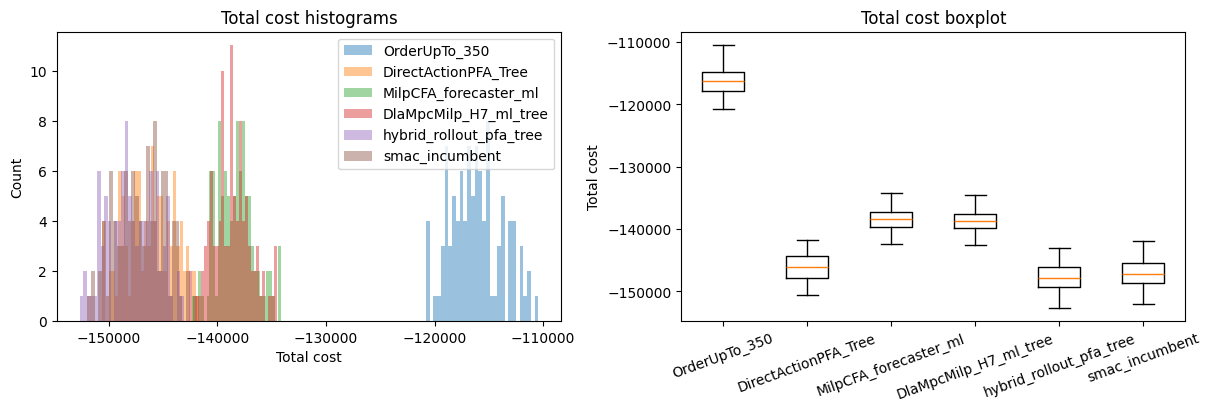

In [27]:
# === Plot total cost distribution and boxplot ===
from inventory.evaluation.plotting import plot_totals_hist_and_box
_ =plot_totals_hist_and_box(totals_by_policy)

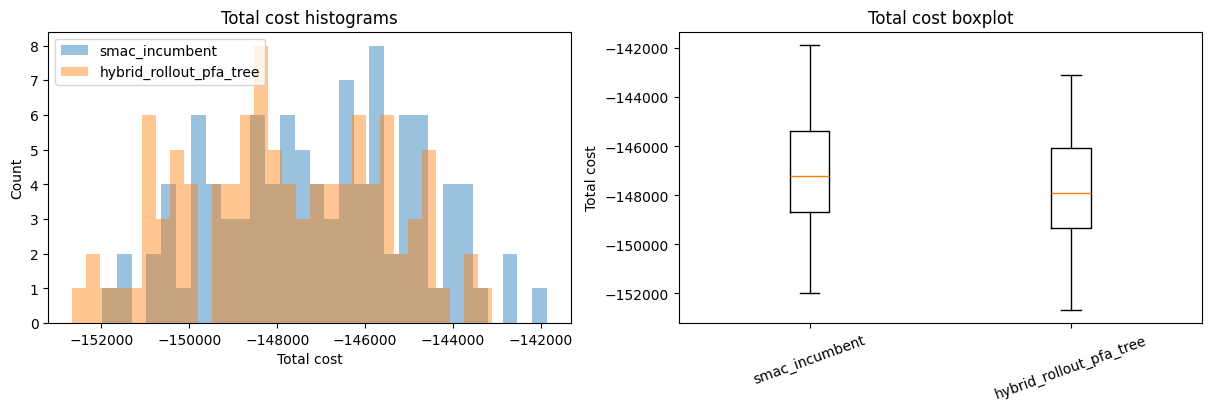

In [29]:
# === Plot total cost distribution and boxplot ===
from inventory.evaluation.plotting import plot_totals_hist_and_box
_ =plot_totals_hist_and_box({k: totals_by_policy[k] for k in ['smac_incumbent', 'hybrid_rollout_pfa_tree']})

---

## 🔬 Results, Insights & Discussion

In this section, we summarize and interpret the main findings of the experiment in a research-paper style. We first present the key results in compact form, using a result table and a main comparison plot to highlight overall performance differences.

We then discuss what these results teach us by interpreting the baseline–candidate comparison, the default–variation comparison within the candidate class, and their relevance for the underlying modeling question.

Based on this, we answer the research questions directly and conclude with implications and possible next steps.

### What are the main results?
- compact result table
- one main comparison plot
- short interpretation of who performs best
- ***Results 1***: 

### What do we learn?
- interpret baseline vs candidate
- interpret candidate default vs candidate variation
- connect result back to the modeling question
- ***Learning 1***: 

### How would we answer our reseach questions?
- ***RQ1***: 
- ***RQ2***: 

### What next steps would we plan?
- Address implications and next steps
- ***Next step1***:


---

## 🥊 Punchline

In this section, we distill the main punchline of the experiment into an exam-relevant takeaway. Think of it as the “if you remember only two things, remember these” message.


- ***Takeaway 1***: Lorem ipsum

- ***Takeaway 2***: Dolor sit 

---

# Appendix

## 🏎️ Appendix A: Dynamics of the system under policy regimes

In this section, we study the dynamics of the system under the different policy regimes. We first inspect one strict-CRN trajectory for all three policies to compare their actions and resulting system behavior. We then visualize many trajectories together with their mean paths to identify broader dynamic patterns.

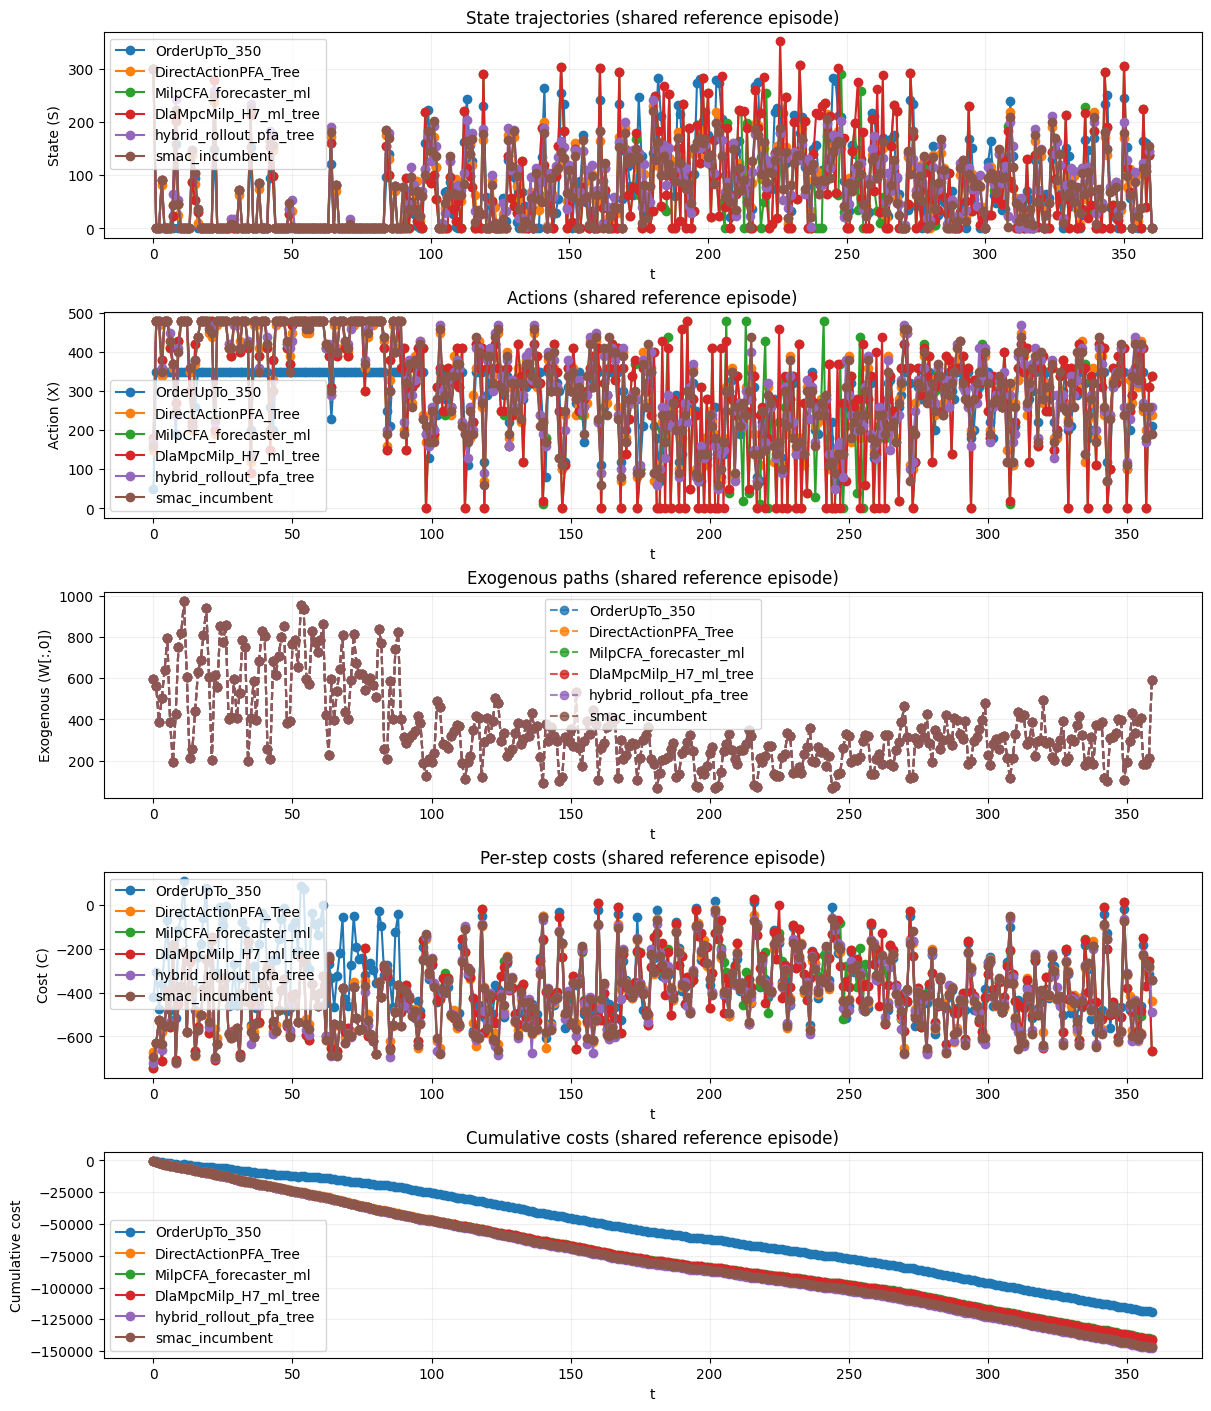

In [28]:
# === Visual dynamics for one shared *reference episode* per policy ===
from inventory.evaluation.plotting import plot_reference_episode_rollouts_grid
_ = plot_reference_episode_rollouts_grid(
    rollouts,
    #{k: rollouts[k] for k in ['hybrid_rollout_pfa_tree', 'OrderUpTo_350']},
    figsize=(12, 14),
    show=True,
    marker="o",
 )

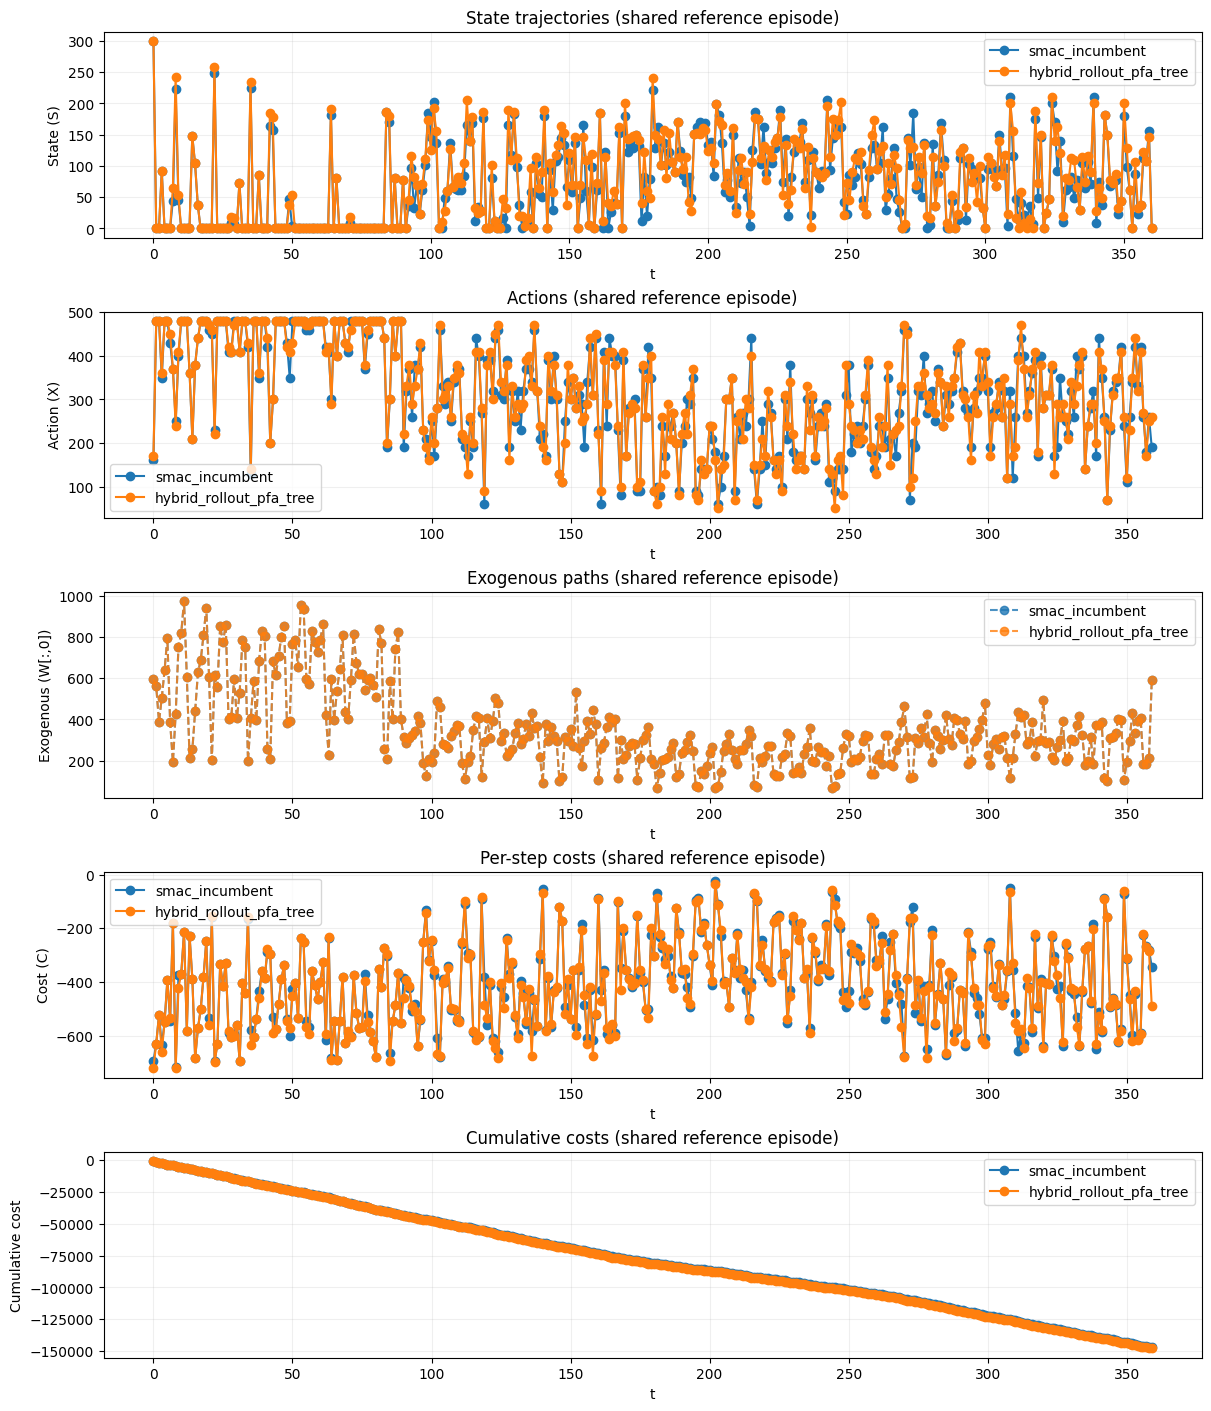

In [30]:
# === Visual dynamics for one shared *reference episode* per policy ===
from inventory.evaluation.plotting import plot_reference_episode_rollouts_grid
_ = plot_reference_episode_rollouts_grid(
    #rollouts,
    {k: rollouts[k] for k in ['smac_incumbent', 'hybrid_rollout_pfa_tree']},
    figsize=(12, 14),
    show=True,
    marker="o",
 )

In [ ]:
# === Visual dynamics across many episodes (overlay: faint lines = episodes, bold line = mean) ===

n_plot_episodes = 50

rollouts_mc = system.collect_policies_crn_rollouts_mc(
    policies,
    S0,
    T=T,
    n_episodes=n_plot_episodes,
    seed0=seed0,
    info=eval_info,
 )

from inventory.evaluation.plotting import plot_rollouts_overlay_grid
_ = plot_rollouts_overlay_grid(
    rollouts_mc,
    figsize=(12, 14),
    alpha_episode=0.12,
    linewidth_episode=1.0,
    linewidth_mean=2.8,
    title_suffix=f"(CRN-MC overlay; n={n_plot_episodes})",
    show=True,
 )

---

## 📈 Appendix B: Statistical validation

In this section, we statistically compare the baseline policy against **one focal hybrid policy at a time**.

Because this notebook now contains more than one hybrid policy, the summary above should be read first. The paired-delta appendix below then lets us choose one treatment policy explicitly via `focal_policy_name` in the next code cell.

Given the hypothesis of interest, we define the paired-delta direction, compute the paired differences, and assess their normality. We then use these paired deltas to perform both a frequentist and a Bayesian hypothesis test.

Finally, we summarize the findings and interpret their meaning in context.

**Notes**

- This appendix supports the statistical comparison of **two** policies only. Multi-policy comparisons require different assumptions and a separate method, which is not implemented here.
- The frequentist and Bayesian hypotheses may differ slightly. They are stated explicitly in their respective sections.


### ⚖️ Paired Delta analysis

Our default hypothesis of interest is that the treatment policy has a positive effect, that is, it achieves a **lower total cost** than the control policy. We therefore compute the paired deltas in the corresponding direction and examine their distribution using a normality diagnostic. This prepares the ground for the subsequent frequentist and Bayesian analyses.


In [ ]:
# === Get paired deltas summary ===
from inventory.evaluation.notebooks.reports import print_paired_delta_summary

reports = print_paired_delta_summary(
    totals_by_policy,
    baseline_name="baseline",
    higher_is_better=False,
)

In [ ]:
policies = {
    'OrderUpTo_350': OrderUpTo_350,
    'DirectActionPFA_Tree': DirectActionPFA_Tree,
    'MilpCFA_forecaster_ml': MilpCFA_forecaster_ml,
    'DlaMpcMilp_H7_ml_tree':DlaMpcMilp_H7_ml_tree,
    #'hybrid_rollout_heuristic': hybrid_rollout,
    'hybrid_rollout_pfa_tree': hybrid_rollout_pfa_tree,
    "smac_incumbent": smac_incumbent_policy,
}

In [48]:
# === Calculate paired deltas ===
from inventory.evaluation.notebooks.reports import compute_crn_deltas

# Note: the "other_policy" argument controls which paired deltas are computed (e.g. candidate vs. candidate_var)
crn_deltas = compute_crn_deltas(
    totals_by_policy,
    #base_policy="baseline",
    #other_policy="candidate",
    base_policy="smac_incumbent",
    other_policy="hybrid_rollout_pfa_tree",
    plot=False,
)

=== Normality Diagnostics ===
Statistics: n=100, mean=-746.24, std=287.70
Shapiro–Wilk:       stat=0.9926, p=0.8661
D’Agostino–Pearson: stat=0.2044, p=0.9029
=== Decision at α = 0.05 ===
- Both tests fail to reject normality.


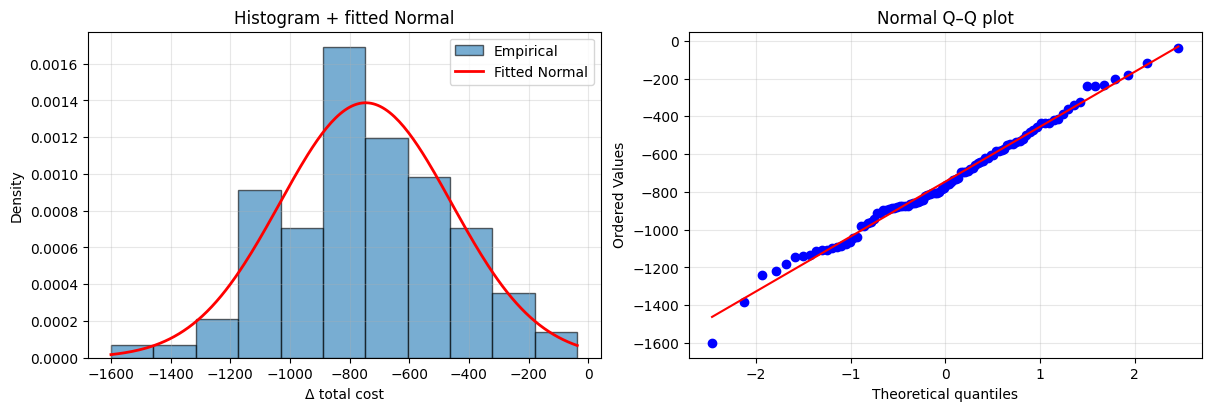

In [49]:
# === Normality diagnostics for paired deltas ===
from inventory.evaluation.deltas import normality_diagnostics
_ = normality_diagnostics(crn_deltas)

---

### ⏱️ Frequentist analysis
In this section, we analyze the policy comparison from a frequentist perspective. Based on the paired deltas, we test whether the observed performance difference is statistically significant under the hypothesis of interest.

Depending on the distribution of the paired differences, we apply an appropriate test and interpret the resulting p-value, test statistic, and confidence interval.

In [50]:
# === Frequentist evaluation of CRN deltas ===
from inventory.evaluation.notebooks.reports import print_frequentist_report_for_crn_deltas

_ = print_frequentist_report_for_crn_deltas(crn_deltas)

=== Frequentist CRN Paired-Delta Analysis (Treatment=B vs Control=A) ===
Objective: cost | Delta convention: treatment-control
Delta definition: Δ = Treatment - Control (B - A)
Direction: B better than A ⇔ Δ < 0 | Win-rate rule: B better ⇔ Δ < 0
Claim: B better than A (one-sided, pre-specified)
Alternative used: less | alpha=0.050

--- Hypotheses ---
H0: E[Δ] = 0  (no average difference)
H1: E[Δ] < 0  (B better than A, because B better ⇔ Δ < 0)

--- Descriptives (deltas) ---
n=100 | mean=-746.2365 | median=-773.6250 | std=287.6972 | dz=-2.5938
min=-1599.9400 | max=-36.9400
win rate (B beats A)=1.0000 (wins=100, losses=0, ties=0)

--- Normality check (Shapiro on deltas) ---
stat=0.9926 | p=0.8661 | reject@0.050=False

--- Hypothesis tests ---
Paired t-test (Δ vs 0): t=-25.9383 (df=99) | p=0.0000 (<1e-4) | CI(mean)=[-803.3219, -689.1511]
Wilcoxon: W=0.0000 | p=0.0000 (<1e-4)
Sign test: p=0.0000 (<1e-4) | n_eff=100 (zeros ignored)
Permutation (sign-flip mean): p=0.0000 (<1e-4) (n_perm=200

### 🔬 Insights

***Frequentist Analysis***

- **Hypothesis**: Here, we formulate the frequentist null and alternative hypotheses for the paired policy comparison.

- **Results**: Here, we report the main outputs of the frequentist test, including the test statistic, p-value, and confidence interval.

- **Interpretation**: Here, we interpret the frequentist results and relate them back to the original policy question.

---

### 🎰 Bayesian analysis
In this section, we examine the policy comparison from a Bayesian perspective. Based on the paired deltas, we estimate the probability that one policy outperforms the other and quantify the uncertainty around the effect. the goal is to assess how credible the observed performance advantage is, how large the effect is likely to be, and what this implies for our decision-making problem.

This complements the frequentist view by focusing on credible effect sizes and probabilistic interpretation rather than statistical significance alone.

In [51]:
# === Bayesian evaluation of CRN deltas ===
from inventory.evaluation.notebooks.reports import print_bayesian_report_for_crn_deltas

print_bayesian_report_for_crn_deltas(
    crn_deltas,
    better="lower",
    deltas_are="B_minus_A",
    random_state=0,
    n_draws=200_000,
    cred_level=0.95,
    delta=50.0,
    rope=0.05,
    mode="full",
)

Decision @ 0.95: PASS ✅   P(E[B-A] <= -50) = 1.000
--------------------------------------------------
Bayesian Policy Comparison (paired CRN, episode TOTAL cost)
n episodes: 100
Interpretation: deltas = B - A

Data summary (deltas = B-A):
  sample mean: -746.237
  sample sd  :  287.697
  min / max  : -1599.94 / -36.94

Posterior on mean treatment effect (E[B-A]):
  95.0% CrI: [-801.618, -690.103]
  P(E[B-A] < 0): 1.000
  P(E[B-A] <= -50): 1.000
  ROPE ±0.05: P(|E[B-A]|<=rope) = 0.000

Verdict:
  Strong evidence: P(E[B-A] <= -50) = 1.000


### 🔬 Insights

***Bayesian Analysis***

- **Hypothesis**: Here, we formulate the Bayesian hypothesis of interest for the paired policy comparison.
- **Results**: Here, we summarize the posterior results, including credible intervals and the probability that one policy outperforms the other.
- **Interpretation**: Here, we interpret the Bayesian findings and discuss what they imply for the policy comparison.

---

## 🚀 Appendix C: Further variatons

In this section, you can explore further variations of the candidate policy to generate additional insights.

To proceed, copy the **Policy Definition** section, modify the policy as needed, and rerun the evaluation pipeline. If appropriate, you may also use the appendices to support a deeper analysis of the new variation.

### 🤖 🪄Additional Policy definition

In [ ]:
# === Copy and adjust 🤖 🪄Additional Policy definition section here ===

### 🪄Additional Experiment run and Strict-CRN policy evaluation

In [ ]:
# === Copy and run 🤖 🪄Additional Experiment run and Strict-CRN policy evaluationsection here ===

### 🏎️ Additional Appendix A: Dynamics of the system under policy regimes section

In [ ]:
# === Copy and run 🏎️ Appendix A: Dynamics of the system under policy regimes section here ===

### 🔍 Additional Appendix B: Statistical validation section 

In [ ]:
# === Copy and run 🔍 Appendix B: Statistical validation section here ===

### 🔬 Additional Insights

In [ ]:
# === Insert 🔬 Additional Insights here ===

---

---

## 🔮 Appendix D: Information model definition

In this section, we specify (if relevant) which information model the policy uses to anticipate future demand. We begin by formulating the forecasting task and explaining why a forecast is needed in this setting. We then describe the training data, including the features and labels used for learning.

Next, we train the selected forecaster variants and conclude with a short sanity check to ensure that the resulting predictions are reasonable before they are embedded into the policy.

In [ ]:
# === Forecasting task ===
# - what is being predicted?
# - why is forecasting needed here?

In [ ]:
# === Forecaster training data & training ===
# - where the data comes from
# - short explanation of features and labels

# - fit constant / linear / GBDT / MLP / quantile forecaster

In [ ]:
# === Forecaster sanity check ===
# - small plot or a few example predictions

---